# TBD Phase 2: Performance & Computing Models

## Introduction
In this lab, you will compare the performance and computing models of four popular data processing engines: **Polars, Pandas, DuckDB, and PySpark**.

You will explore:
- **Performance**: Single-node processing speed, parallel execution, and memory usage.
- **Scalability**: How performance changes with the number of cores (single-node) and executors (cluster).
- **Computing Models**: Out-of-core vs. In-memory processing, and Eager vs. Lazy execution.

### Engine Capabilities
The following table summarizes the key capabilities of the engines we will be testing. Use this as a reference.

| Engine | Query Optimizer | Distributed | Arrow-backed | Out-of-Core | Parallel | APIs | GPU Support |
|---|---|---|---|---|--|---|---|
| **Pandas** | ❌ | ❌ | optional ≥ 2.0 | ❌ | ❌ | DataFrame | ❌ |
| **Polars** | ✅ | ❌ | ✅ | ✅ | ✅ | DataFrame | ✅ (opt) |
| **PySpark** | ✅ | ✅ | Pandas UDF/IO | ✅ | ✅ | SQL, DataFrame | ❌ (no GPU) |
| **DuckDB** | ✅ | ❌ | ✅ | ✅ | ❌ | SQL, Relational API | ❌ |

## Prerequisites
Ensure you have the necessary libraries installed.

In [1]:
# %pip install polars pandas duckdb pyspark faker deltalake memory_profiler pyarrow
"""
    Biblioteki zostały zainstalowane lokalnie do środowiska wirtualnego
"""

'\n    Biblioteki zostały zainstalowane lokalnie do środowiska wirtualnego\n'

In [2]:
import polars as pl
import pandas as pd
import duckdb
from pyspark.sql import SparkSession
from faker import Faker
import numpy as np
import os
import time
import psutil
from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import copy

In [3]:
# Initialize Spark (Single Node)
spark = SparkSession.builder \
    .appName("BigDataLab2") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/24 14:58:44 WARN Utils: Your hostname, miklap, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/24 14:58:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/24 14:58:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Part 1: Data Generation

We will generate a synthetic dataset simulating social media posts with a rich schema.

**Schema**:
- `post_id` (String): Unique identifier.
- `user_id` (Integer): User identifier.
- `timestamp` (DateTime): Time of post.
- `content` (String): Text content.
- `likes` (Integer): Number of likes.
- `views` (Integer): Number of views.
- `category` (String): Post category.
- `tags` (List[String]): Hashtags.
- `location` (String): User location.
- `device` (String): Device used (Mobile, Web, etc.).
- `latency` (Float): Network latency.
- `error_rate` (Float): Error rate during upload.

In [5]:
def generate_data(num_records=1_000_000, output_path="./social_media_data.parquet"):
    fake = Faker()

    print(f"Generating {num_records} records...")

    # Generate data using numpy for speed where possible
    data = {
        "post_id": [fake.uuid4() for _ in range(num_records)],
        "user_id": np.random.randint(1, 100_000, num_records),
        "timestamp": pd.date_range(start="2023-01-01", periods=num_records, freq="s").to_numpy().astype("datetime64[us]"),
        "likes": np.random.randint(0, 10_000, num_records),
        "views": np.random.randint(0, 1_000_000, num_records),
        "category": np.random.choice(["Tech", "Health", "Travel", "Food", "Fashion", "Politics", "Sports"], num_records),
        "tags": [np.random.choice(["#viral", "#new", "#trending", "#hot", "#update"], size=np.random.randint(1, 4)).tolist() for _ in range(num_records)],
        "location": np.random.choice(["USA", "UK", "DE", "PL", "FR", "JP", "BR"], num_records),
        "device": np.random.choice(["Mobile", "Desktop", "Tablet"], num_records),
        "latency": np.random.uniform(10.0, 500.0, num_records),
        "error_rate": np.random.beta(1, 10, num_records),
        "content": [fake.sentence() for _ in range(min(num_records, 1000))] * (num_records // 1000 + 1)
    }

    # Trim to exact size
    data["content"] = data["content"][:num_records]

    df = pd.DataFrame(data)

    print("Writing to Parquet...")
    df.to_parquet(output_path, engine="pyarrow")
    print(f"Data saved to {output_path}")

# Generate 5 million records
generate_data(num_records=5_000_000)

Generating 5000000 records...
Writing to Parquet...
Data saved to ./social_media_data.parquet


## Part 2: Measuring Performance

### 2.1 Execution Time
Use `%time` or `%timeit` to measure execution time.

In [6]:
# Example: Measuring time for all engines
print("--- Performance Benchmark Example ---")

# Pandas
print("Pandas Load Time:")
%time df_pd = pd.read_parquet("social_media_data.parquet")

# Polars
print("\nPolars Load Time:")
%time df_pl = pl.read_parquet("social_media_data.parquet")

# DuckDB
print("\nDuckDB Query Time:")
%time duckdb.sql("SELECT count(*) FROM 'social_media_data.parquet'").show()

# PySpark
print("\nSpark Load Time:")
%time df_spark = spark.read.parquet("social_media_data.parquet"); df_spark.count()

--- Performance Benchmark Example ---
Pandas Load Time:
CPU times: user 10.6 s, sys: 9.13 s, total: 19.8 s
Wall time: 12.4 s

Polars Load Time:
CPU times: user 2.38 s, sys: 3.27 s, total: 5.65 s
Wall time: 2.29 s

DuckDB Query Time:
┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5000000 │
└──────────────┘

CPU times: user 5.35 ms, sys: 36 ms, total: 41.3 ms
Wall time: 30.4 ms

Spark Load Time:


CPU times: user 22 ms, sys: 59.4 ms, total: 81.5 ms
Wall time: 10.5 s


5000000

## Part 3: Student Tasks

### Task 1: Performance & Scalability (Single Node)

**Goal**: Benchmark the engines and test how they scale with available CPU cores.

**Instructions**:
1.  **Define Queries**: Create 3 distinct queries of your own choice. They should cover:
    -   **Query A**: A simple aggregation (e.g., grouping by a categorical column and calculating means).
    -   **Query B**: A window function or more complex transformation.
    -   **Query C**: A join (e.g., self-join or join with a smaller generated table) with filtering.
2.  **Benchmark**: Implement these queries in **Pandas, Polars, DuckDB, and PySpark**.
    -   Measure **Execution Time** using `%time` or `time.time()`.
    -   Measure **Peak Memory** usage using `memory_profiler` (e.g., `memory_usage()`).
3.  **Scalability Test**: 
    -   SELECT **all engines** that support parallel execution on a single node (e.g., Polars, DuckDB).
    -   Run **all 3 queries** with different numbers of threads/cores (e.g., 1, 2, 4, 8).
    -   Plot the speedup for each query and engine.

**Tip**: 
-   Polars: [polars.thread_pool_size](https://docs.pola.rs/api/python/stable/reference/api/polars.thread_pool_size.html) Please also note that *Thread configuration in Polars requires process restart*
-   DuckDB: `PRAGMA threads=n`
-   Spark: `master="local[n]"`

#### T1.1. Queries definition



---

1. Simple aggregation
```sql
-- SELECT device types and its technical information averages
SELECT
    device,
    count(*) as device_count,
    mean(latency) as avg_altency,
    mean(error_rate) as avg_error_rate
FROM
    db_table
GROUP BY
    device
```

---

2. Window functions
```sql
SELECT
    post_id,
    category,
    DATE(timestamp) AS post_date,
    likes,
    views,
    RANK() OVER (
        PARTITION BY category, DATE(timestamp)
        ORDER BY likes DESC
    ) AS daily_like_rank,
    AVG(views) OVER (
        PARTITION BY category
        ORDER BY timestamp
        ROWS BETWEEN 100 PRECEDING AND CURRENT ROW
    ) AS rolling_avg_views
FROM
    db_table;
```

---

3. JOINs
```sql
-- SELECT all post_ids and get previous post_id of the 1st post uploader (user_id)
WITH posts_ranked AS (
    SELECT
        post_id
        , user_id
        , ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY timestamp DESC
        ) AS userpost_history
    FROM
        db_table
)
SELECT
    cur.user_id as user_id
    , cur.post_id as post_id
    , prev.post_id as prevoius_post_id
FROM
    posts_ranked cur
LEFT JOIN
    posts_ranked prev
ON
    cur.user_id = prev.user_id
    AND cur.userpost_history = prev.userpost_history - 1
```


<!-- ```sql
SELECT
    p1.post_id AS current_post,
    p2.post_id AS previous_post,
    p1.user_id,
    p1.likes AS current_likes,
    p2.likes AS previous_likes,
    p1.timestamp
FROM
    db_table p1
JOIN db_table p2
    ON p1.user_id = p2.user_id
    AND p2.timestamp = (
        SELECT MAX(timestamp)
        FROM db_table
        WHERE user_id = p1.user_id
          AND timestamp < p1.timestamp
   )
WHERE
    p1.likes > p2.likes;
``` -->

---

#### T1.2. Benchmarks

In [4]:
# Your Code Here for Task 1
import utils

# TABLE_LOCATION = "/media/mikic202/Nowy1/uczelnia/semestr_9/social_media_data.parquet"
TABLE_LOCATION = "./social_media_data.parquet"

Pandas

In [8]:
print(" --- Query 1: --- ")
pandas_tim_q1 = utils.benchmark_pandas_time(df_pd, utils.query_aggregation_pandas)
pandas_mem_q1 = utils.benchmark_pandas_memory(df_pd, utils.query_aggregation_pandas)

print("\n\n --- Query 2 --- ")
pandas_tim_q2 = utils.benchmark_pandas_time(df_pd, utils.query_window_pandas)
pandas_mem_q2 = utils.benchmark_pandas_memory(df_pd, utils.query_window_pandas)

print("\n\n --- Query 3 --- ")
pandas_tim_q3 = utils.benchmark_pandas_time(df_pd, utils.query_join_pandas)
pandas_mem_q3 = utils.benchmark_pandas_memory(df_pd, utils.query_join_pandas)

 --- Query 1: --- 
Repeats number: 5
Execution times: [1.572, 1.003, 1.068, 0.787, 0.699]
First time: 1.572s
Mean  time: 1.026s
Best  time: 0.699s
Peak Memory Usage: 3644.141 MiB


 --- Query 2 --- 
Repeats number: 5
Execution times: [15.303, 16.819, 16.845, 17.549, 30.877]
First time: 15.303s
Mean  time: 19.479s
Best  time: 15.303s
Peak Memory Usage: 4863.566 MiB


 --- Query 3 --- 
Repeats number: 5
Execution times: [25.837, 26.698, 25.663, 22.148, 23.06]
First time: 25.837s
Mean  time: 24.681s
Best  time: 22.148s
Peak Memory Usage: 5139.648 MiB


Polars

In [9]:
print(" --- Query 1: --- ")
polars_tim_q1 = utils.benchmark_polars_time(df_pl, utils.query_aggregation_polars)
polars_mem_q1 = utils.benchmark_polars_memory(df_pl, utils.query_aggregation_polars)

print("\n\n --- Query 2 --- ")
polars_tim_q2 = utils.benchmark_polars_time(df_pl, utils.query_window_polars)
polars_mem_q2 = utils.benchmark_polars_memory(df_pl, utils.query_window_polars)

print("\n\n --- Query 3 --- ")
polars_tim_q3 = utils.benchmark_polars_time(df_pl, utils.query_join_polars)
polars_mem_q3 = utils.benchmark_polars_memory(df_pl, utils.query_join_polars)

 --- Query 1: --- 
Repeats number: 5
Execution times: [2.201, 0.343, 0.289, 0.308, 0.289]
First time: 2.201s
Mean  time: 0.686s
Best  time: 0.289s
Peak Memory Usage: 4637.855 MiB


 --- Query 2 --- 
Repeats number: 5
Execution times: [10.002, 8.036, 7.496, 6.851, 6.935]
First time: 10.002s
Mean  time: 7.864s
Best  time: 6.851s
Peak Memory Usage: 7576.902 MiB


 --- Query 3 --- 
Repeats number: 5
Execution times: [6.304, 6.066, 6.073, 5.727, 5.452]
First time: 6.304s
Mean  time: 5.924s
Best  time: 5.452s
Peak Memory Usage: 7390.270 MiB


DuckDB

In [10]:
print(" --- Query 1: --- ")
duck_db_tim_q1 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.AGGREGATION_QUERY)
duck_db_mem_q1 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.AGGREGATION_QUERY)

print("\n\n --- Query 2 --- ")
duck_db_tim_q2 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY)
duck_db_mem_q2 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY)

print("\n\n --- Query 3 --- ")
duck_db_tim_q3 = utils.benchmark_duckdb_time(TABLE_LOCATION, utils.JOIN_QUERY)
duck_db_mem_q3 = utils.benchmark_duckdb_memory(TABLE_LOCATION, utils.JOIN_QUERY)

 --- Query 1: --- 
Repeats number: 5
Execution times: [0.12, 0.09, 0.103, 0.08, 0.062]
First time: 0.120s
Mean  time: 0.091s
Best  time: 0.062s
Peak Memory Usage: 6455.223 MiB


 --- Query 2 --- 
Repeats number: 5


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Execution times: [11.78, 9.506, 9.243, 9.721, 9.195]
First time: 11.780s
Mean  time: 9.889s
Best  time: 9.195s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Peak Memory Usage: 8226.152 MiB


Spark

In [11]:
spark_benchmark_obj = utils.SparkBenchmarkObject(session=spark, df=df_spark)

In [12]:
print(" --- Query 1: --- ")
spark_tim_q1 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.AGGREGATION_QUERY)
spark_mem_q1 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.AGGREGATION_QUERY)
print("\n\n --- Query 2 --- ")
spark_tim_q2 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.WINDOWFUNCTION_QUERY)
spark_mem_q2 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.WINDOWFUNCTION_QUERY)

print("\n\n --- Query 3 --- ")
spark_tim_q3 = utils.benchmark_spark_time(spark_benchmark_obj=spark_benchmark_obj, query=utils.JOIN_QUERY)
spark_mem_q3 = utils.benchmark_spark_memory(spark_benchmark_obj=spark_benchmark_obj, query=utils.JOIN_QUERY)

spark.stop()


 --- Query 1: --- 
Repeats number: 5


Execution times: [4.669, 1.44, 1.065, 1.094, 1.023]
First time: 4.669s
Mean  time: 1.858s
Best  time: 1.023s


Peak Memory Usage: 5968.74609375 MiB


 --- Query 2 --- 
Repeats number: 5


Execution times: [67.166, 66.335, 56.818, 58.243, 56.825]
First time: 67.166s
Mean  time: 61.077s
Best  time: 56.818s


Peak Memory Usage: 5049.66015625 MiB


 --- Query 3 --- 
Repeats number: 5


Execution times: [51.379, 45.472, 44.467, 43.356, 42.712]
First time: 51.379s
Mean  time: 45.477s
Best  time: 42.712s


Peak Memory Usage: 4324.05859375 MiB


#### T1.3. Scalability

In [6]:
MAX_NUMBER_OF_THREADS = 10

**Polars**


Due to Polars requiring a process restart to change the thread configuration, other tests must be run after a kernel restart. The results are saved to a file.

In [14]:
import utils
import csv
import os

# threads_list = [1, 2, 4, 8, 16]
n_threads = 16
os.environ["POLARS_MAX_THREADS"] = str(n_threads)  # ustawienie liczby wątków

import polars as pl

df_pl = pl.read_parquet("social_media_data.parquet")
filename = "save_scalability_result.csv"


def save_scalability_result(filename: str, cores: int, query_name: str, time_seconds: float):
    """
    Zapisuje wynik benchmarku do pliku CSV, dopisując nowy wiersz.

    Args:
        filename (str): nazwa pliku CSV
        cores (int): liczba wątków użytych w benchmarku
        query_name (str): nazwa testowanej funkcji / zapytania
        time_seconds (float): czas wykonania w sekundach
    """
    file_exists = os.path.isfile(filename)

    with open(filename, mode='a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["cores", "query", "time"])

        if not file_exists:
            writer.writeheader()

        writer.writerow({
            "cores": cores,
            "query": query_name,
            "time": time_seconds
        })

In [ ]:

times_per_core_agregation = utils.scalability_polars(df_pl, utils.query_aggregation_polars)
print(f"**Polars for agregation query** Cores: {n_threads:2}, Time: {times_per_core_agregation:.4f} seconds\n")
save_scalability_result(filename, n_threads, "A", times_per_core_agregation)

times_per_core_window = utils.scalability_polars(df_pl, utils.query_window_polars)
print(f"**Polars for window function query** Cores: {n_threads:2}, Time: {times_per_core_window:.4f} seconds\n")
save_scalability_result(filename, n_threads, "B", times_per_core_window)

times_per_core_join= utils.scalability_polars(df_pl, utils.query_join_polars)
print(f"**Polars for join query** Cores: {n_threads:2}, Time: {times_per_core_join:.4f} seconds\n")
save_scalability_result(filename, n_threads, "C", times_per_core_join)

In [ ]:
df = pl.read_csv(filename)

result = {}

for q in df["query"].unique():
    sub = (
        df
        .filter(pl.col("query") == q)
        .sort("cores")
    )
    result[q] = dict(sub.select("cores", "time").iter_rows())

utils.plot_scalability(
    times_per_core_query_dict=result["A"],
    title='Polars Aggregation Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=result["B"],
    title='Polars Window Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=result["C"],
    title='Polars Join Query Scalability'
)

DuckDB

In [15]:

times_per_core_agregation = utils.scalability_duckdb(TABLE_LOCATION, utils.AGGREGATION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for agregation query:")
for cores, t in times_per_core_agregation.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_window = utils.scalability_duckdb(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for window function query:")
for cores, t in times_per_core_window.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_join= utils.scalability_duckdb(TABLE_LOCATION, utils.JOIN_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for DuckDB for join query:")
for cores, t in times_per_core_join.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")


Times per core for DuckDB for agregation query:
Cores:  1, Time: 0.1231 seconds
Cores:  2, Time: 0.0910 seconds
Cores:  4, Time: 0.0750 seconds
Cores:  8, Time: 0.0739 seconds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Times per core for DuckDB for join query:
Cores:  1, Time: 12.4194 seconds
Cores:  2, Time: 10.3779 seconds
Cores:  4, Time: 9.3040 seconds
Cores:  8, Time: 9.4178 seconds


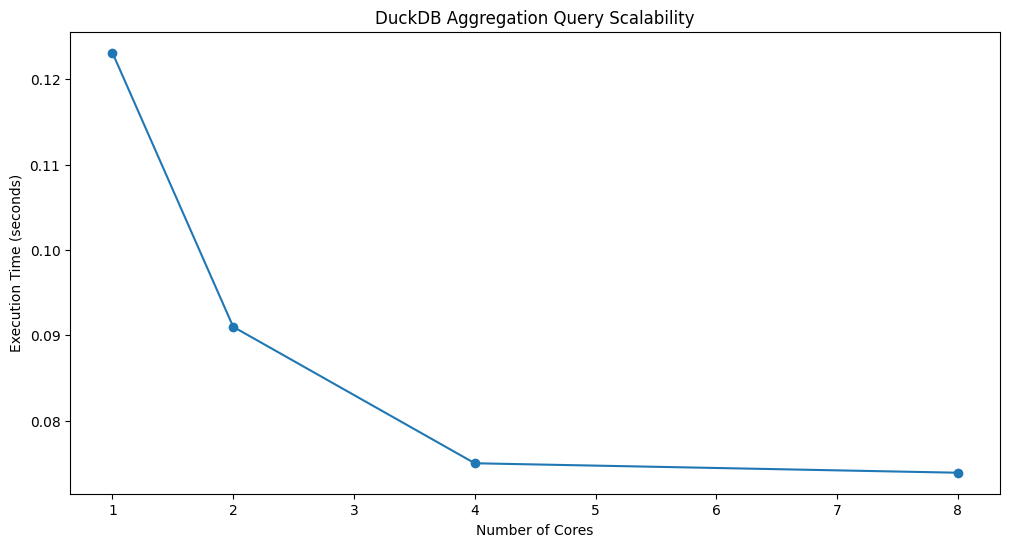

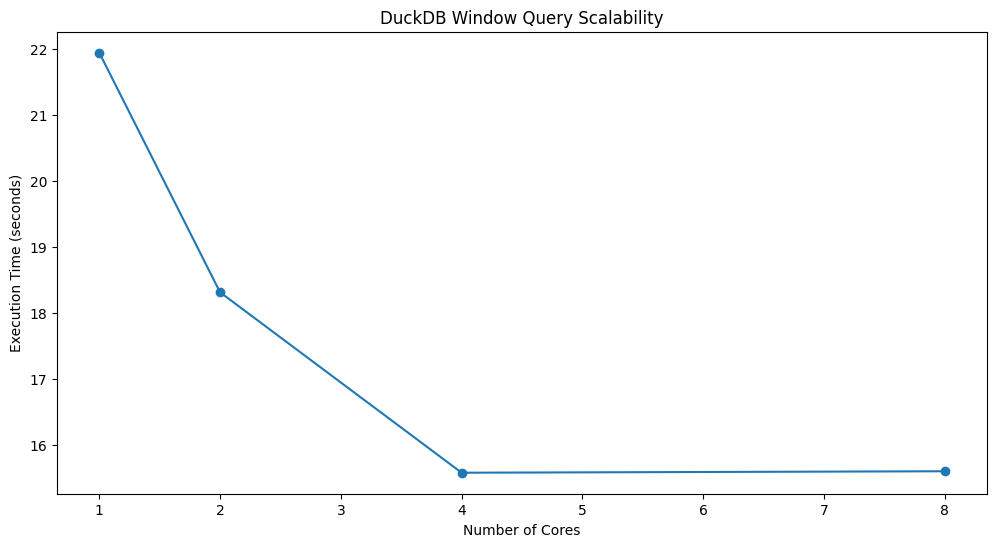

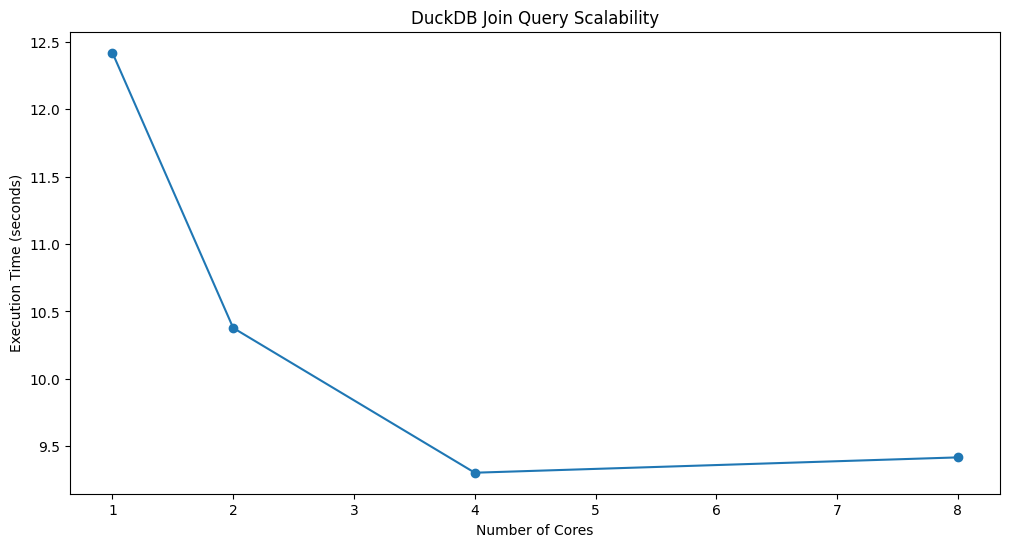

In [16]:
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_agregation,
    title='DuckDB Aggregation Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_window,
    title='DuckDB Window Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_join,
    title='DuckDB Join Query Scalability'
)


Spark

In [7]:

times_per_core_agregation = utils.scalability_spark(TABLE_LOCATION, utils.AGGREGATION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for agregation query:")
for cores, t in times_per_core_agregation.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_window = utils.scalability_spark(TABLE_LOCATION, utils.WINDOWFUNCTION_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for window function query:")
for cores, t in times_per_core_window.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")

times_per_core_join= utils.scalability_spark(TABLE_LOCATION, utils.JOIN_QUERY, max_number_of_threads=MAX_NUMBER_OF_THREADS)
print("Times per core for Spark for join query:")
for cores, t in times_per_core_join.items():
    print(f"Cores: {cores:2}, Time: {t:.4f} seconds")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/24 16:16:08 WARN Utils: Your hostname, miklap, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/24 16:16:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/24 16:16:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Times per core for Spark for agregation query:
Cores:  1, Time: 5.2361 seconds
Cores:  2, Time: 5.7116 seconds
Cores:  4, Time: 4.8997 seconds
Cores:  8, Time: 4.3239 seconds


Times per core for Spark for window function query:
Cores:  1, Time: 87.8385 seconds
Cores:  2, Time: 89.8506 seconds
Cores:  4, Time: 76.1889 seconds
Cores:  8, Time: 70.8219 seconds


Times per core for Spark for join query:
Cores:  1, Time: 56.5932 seconds
Cores:  2, Time: 61.0444 seconds
Cores:  4, Time: 52.1327 seconds
Cores:  8, Time: 51.2634 seconds


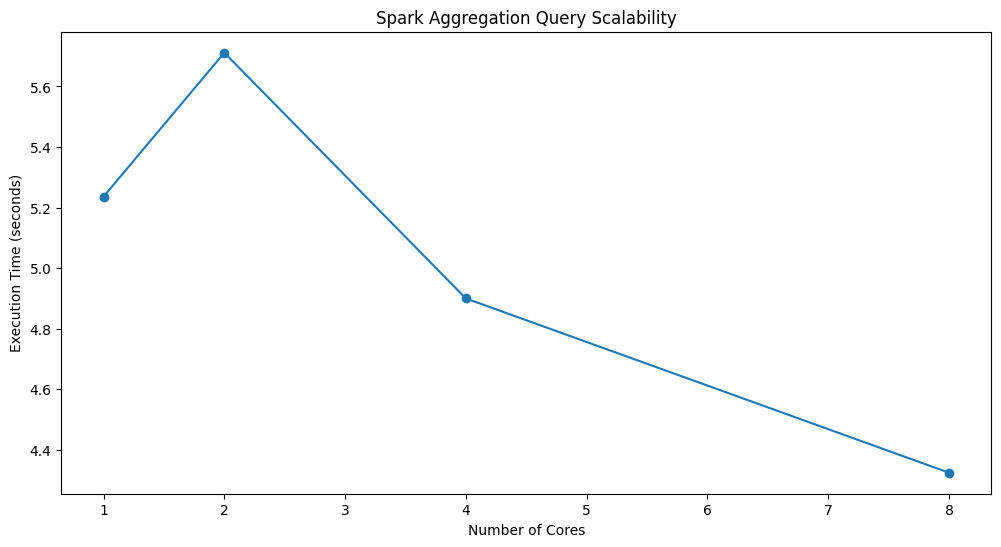

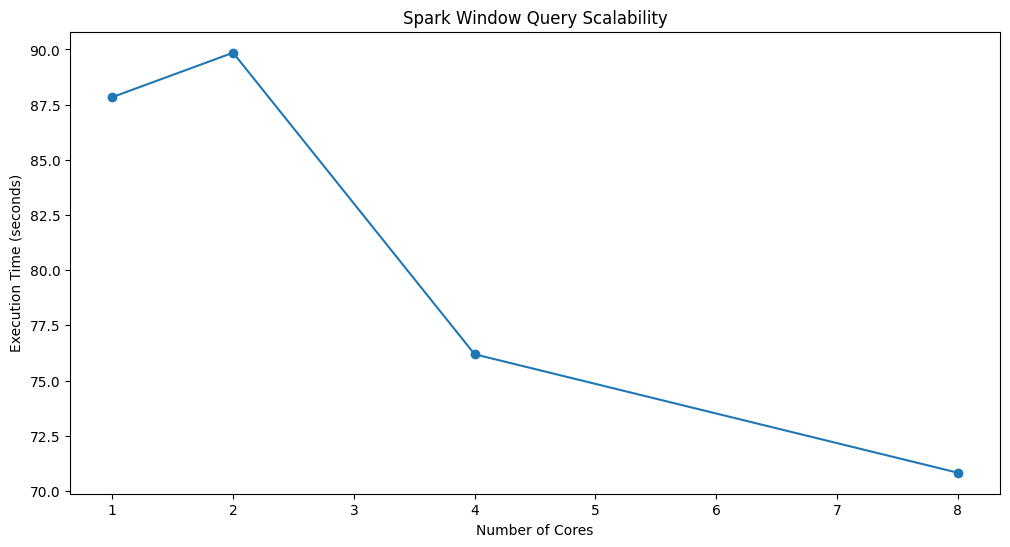

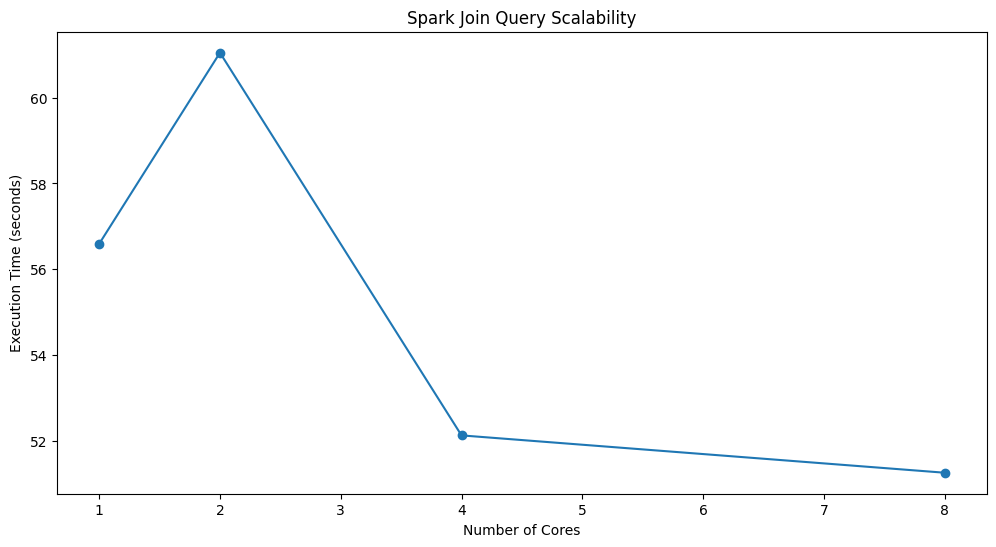

In [8]:
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_agregation,
    title='Spark Aggregation Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_window,
    title='Spark Window Query Scalability'
)
utils.plot_scalability(
    times_per_core_query_dict=times_per_core_join,
    title='Spark Join Query Scalability'
)

### Task 2: Spark on Cluster

**Goal**: Compare Single Node performance vs. Spark on a Cluster.

**Instructions**:
1.  **Infrastructure**: Use the infrastructure from **Phase 1** (Google Dataproc). You may need to modify your Terraform code to adjust the cluster configuration (e.g., number of worker nodes).
2.  **Environment**: The easiest way to run this is via **Google Workbench** connected to your Dataproc cluster.
3.  **Upload Data**: Upload the generated `social_media_data.parquet` to HDFS or GCS.
    -   **Tip**: For better performance, consider **partitioning** the data (e.g., by `category` or `date`) when saving it to the distributed storage. This allows Spark to optimize reads.
4.  **Run Queries**: Run your PySpark queries from Task 1 on the cluster.
5.  **Scalability Test**: 
    -   Run the queries with different numbers of **worker nodes** (e.g., 2, 3, 4).
    -   You can achieve this by resizing the cluster (manually or via Terraform) or by configuring the number of executors in Spark.
6.  **Analyze**:
    -   How does the cluster performance compare to your local machine?
    -   Did adding more nodes/executors linearly improve performance?
    -   **Tip**: If Spark is slower than single-node engines, consider **increasing the dataset size** (e.g., generate 10M+ records or duplicate the data). Spark's overhead is significant for small data, and its true power appears when data exceeds single-node memory.

In [13]:
df = spark.read.parquet(TABLE_LOCATION)
df.write.partitionBy("category").mode("overwrite").parquet("social_media_data_partitioned.parquet")

We partitioned the file using the code above, then uploaded the partitioned data to the bucket using
`gsutil cp -r social_media_data_partitioned.parquet gs://tbd-2025z-318407-state/data/social_media_data_partitioned.parquet`.

Next, we created the file [dataproc_pyspark_test.py](https://github.com/mikic202/tbd-workshop-1-2025Z/blob/dev-tbd-workshop-pahse2/notebooks/dataproc_pyspark_test.py)
, which contains a slightly modified version of the functions used for local testing. Several adjustments were required to ensure the code would run correctly on Dataproc.

Finally, we submitted the job to our cluster using the following command:
`gcloud dataproc jobs submit pyspark dataproc_pyspark_test.py --cluster=tbd-cluster --region=europe-west1`.
Running this job produced the following results:

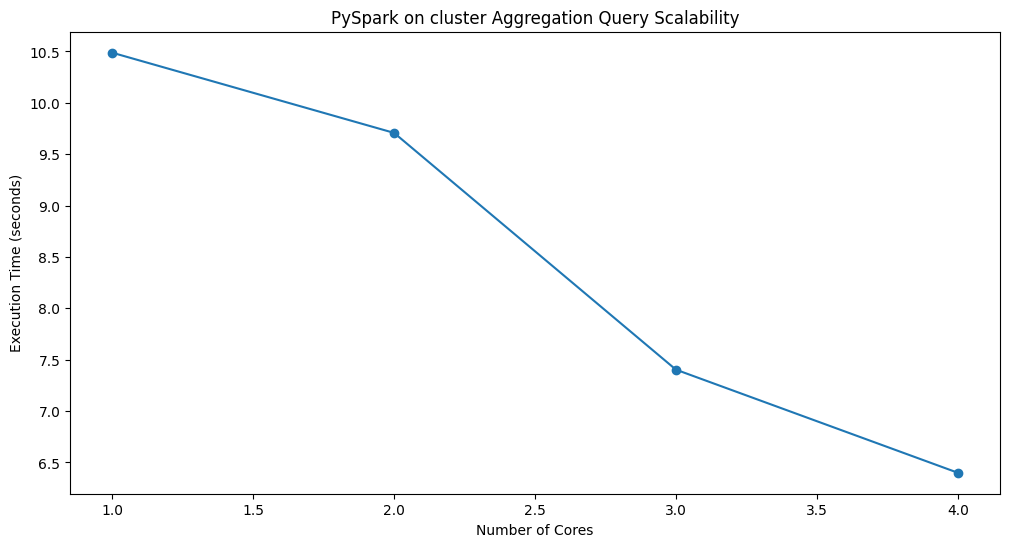

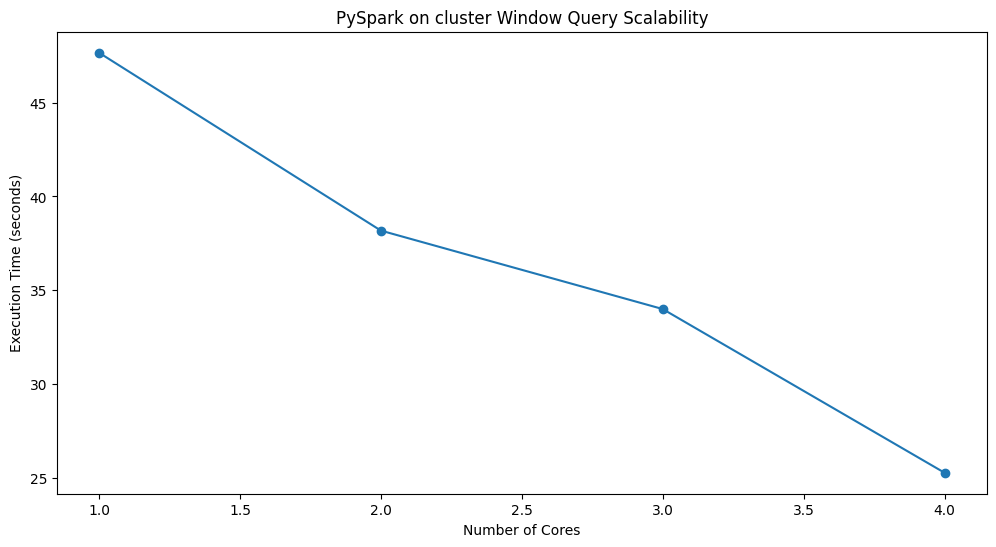

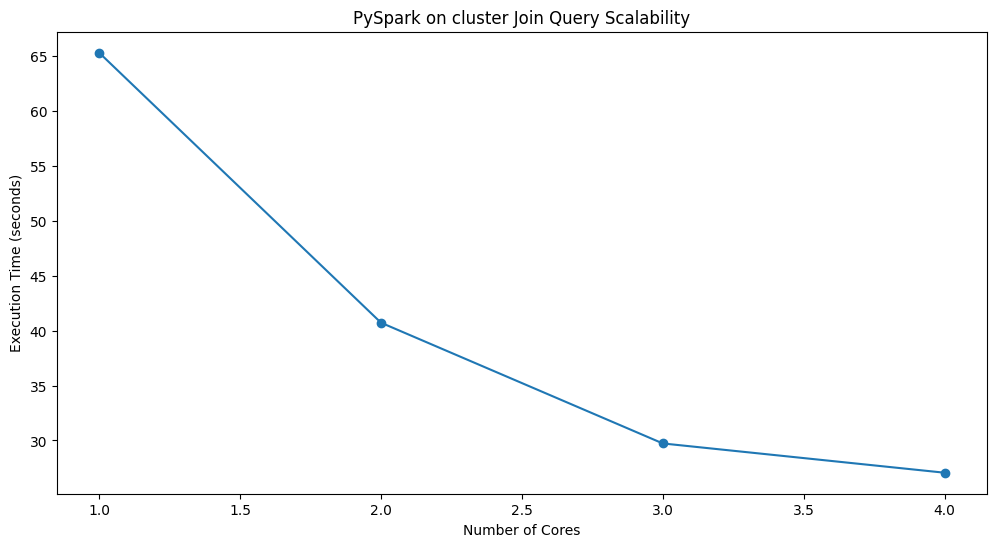

In [9]:
mean_execution_times_aggr = {1: 10.4872, 2: 9.7069, 3: 7.4032, 4: 6.4003}
mean_execution_times_window = {1: 47.6567, 2: 38.1815, 3: 34.0026, 4: 25.2833}
mean_execution_times_join = {1: 65.2939, 2: 40.7196, 3: 29.7292, 4: 27.0644}

utils.plot_scalability(
    times_per_core_query_dict=mean_execution_times_aggr,
    title='PySpark on cluster Aggregation Query Scalability'
)

utils.plot_scalability(
    times_per_core_query_dict=mean_execution_times_window,
    title='PySpark on cluster Window Query Scalability'
)

utils.plot_scalability(
    times_per_core_query_dict=mean_execution_times_join,
    title='PySpark on cluster Join Query Scalability'
)

### Task 3: Execution Modes & Analysis

**Goal**: Deep dive into execution models and limitations.

**Instructions**:
1.  **Lazy vs. Eager vs. Streaming**:
    -   Use **Polars**. Compare the **Execution Time** and **Peak Memory** of:
        -   Eager execution (`read_parquet` -> filter).
        -   Lazy execution (`scan_parquet` -> filter -> `collect()`).
        -   Streaming execution (`scan_parquet` -> filter -> `collect(streaming=True)`).
2.  **Polars Limitations**:
    -   Identify a scenario where Polars might struggle compared to Spark (e.g., memory limits).
3.  **Decision Boundary**:
    -   Based on your findings, when would you recommend switching from a single-node tool (Polars/DuckDB) to a distributed engine (Spark)?

In [3]:
df_pl = pl.read_parquet(TABLE_LOCATION)

print(" --- Eager: --- ")
polars_tim_q1 = utils.benchmark_polars_time(df_pl, utils.query_aggregation_polars)
polars_mem_q1 = utils.benchmark_polars_memory(df_pl, utils.query_aggregation_polars)

df_pl = pl.scan_parquet(TABLE_LOCATION)

print(" --- Lazy: --- ")
polars_tim_q1 = utils.benchmark_polars_time(df_pl, utils.query_aggregation_polars_lazy)
polars_mem_q1 = utils.benchmark_polars_memory(df_pl, utils.query_aggregation_polars_lazy)


print(" --- Lazy Streaming: --- ")
polars_tim_q1 = utils.benchmark_polars_time(df_pl, utils.query_aggregation_polars_lazy_streaming)
polars_mem_q1 = utils.benchmark_polars_memory(df_pl, utils.query_aggregation_polars_lazy_streaming)


 --- Eager: --- 
Repeats number: 5
Execution times: [0.285, 0.206, 0.212, 0.234, 0.201]
First time: 0.285s
Mean  time: 0.227s
Best  time: 0.201s
Peak Memory Usage: 2366.801 MiB
 --- Lazy: --- 
Repeats number: 5
Execution times: [0.178, 0.175, 0.151, 0.191, 0.143]
First time: 0.178s
Mean  time: 0.168s
Best  time: 0.143s
Peak Memory Usage: 2498.668 MiB
Repeats number: 5
Execution times: [0.068, 0.05, 0.056, 0.059, 0.055]
First time: 0.068s
Mean  time: 0.058s
Best  time: 0.050s
Peak Memory Usage: 2613.812 MiB


2. **Polars limitations**

    - Polars, as a single-node tool, is limited to the machine's RAM capacity and free disk space, where it is run.
    So when the heavy dataset is loaded, the size that exceeds the machine's resources, Polar might not handle it and encounter *Out Of Memory Error*.

    - Current Polars version ([documentation <Jan 2026>](https://docs.pola.rs/user-guide/concepts/streaming/)) does not support streaming for every possible operation. When streaming is a key functionability in the given purpose, then using Polars might not be the best choice. 


3. **Decision Boundry** - switching from single-node tool to distributed one

    - Going for a distributed tool such as Spark is usefull especially when there are available distributed resources, such asaccess to clusters on cloud platforms.

    - If the dataset that is being processed is large and exceeds local machine's available resources then Spark have great power of running on many machines at once.

    - While the main purpose of using streaming in single-node tools is to save the memory, Spark on the other hand is prepared to process data in real time. If its a key feature then Spark is a go-to tool.

    - Polars is an emerging library and does not yet have the ecosystem and the same level of community and enterprise support as mature and established solutions such as Spark. 

---

In [ ]:
"""
    File: notebooks/utils.py
"""


import polars as pl
import pandas as pd
import duckdb
import pyspark.sql
from pyspark.sql import SparkSession

import numpy as np
import timeit
from memory_profiler import memory_usage
from typing import Callable, Any
import matplotlib.pyplot as plt

# Part 3    ## Task 1

### Queries:

AGGREGATION_QUERY = """
-- Select device types and its technical information averages
SELECT
    device, COUNT(*) AS device_count,
    AVG(latency) AS avg_latency, AVG(error_rate) AS avg_error_rate
FROM
    %s
GROUP BY
    device
"""

WINDOWFUNCTION_QUERY = """
SELECT
    post_id,
    category,
    DATE(timestamp) AS post_date,
    likes,
    views,
    RANK() OVER (
        PARTITION BY category, DATE(timestamp)
        ORDER BY likes DESC
    ) AS daily_like_rank,
    AVG(views) OVER (
        PARTITION BY category
        ORDER BY timestamp
        ROWS BETWEEN 100 PRECEDING AND CURRENT ROW
    ) AS rolling_avg_views
FROM
    %s
"""

JOIN_QUERY = """
-- Select all post_ids and get previous post_id of the 1st post uploader (user_id)
WITH posts_ranked AS (
    SELECT
        post_id
        , user_id
        , ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY timestamp DESC
        ) AS userpost_history
    FROM
        %s
)
SELECT
    cur.user_id as user_id
    , cur.post_id as post_id
    , prev.post_id as prevoius_post_id
FROM
    posts_ranked cur
LEFT JOIN
    posts_ranked prev
ON
    cur.user_id = prev.user_id
    AND cur.userpost_history = prev.userpost_history - 1
"""


### Benchmark:

N_REPEATS = 5


#### Data tables

DEFAULT_DATA_TABLE_NAME = "db_table"


#  -- -- -- -- --  PANDAS -- -- -- -- --


# --- Query A: AGGREGATION ---
def query_aggregation_pandas(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("device")
        .agg(
            device_count=("device", "count"),
            avg_latency=("latency", "mean"),
            avg_error_rate=("error_rate", "mean"),
        )
        .reset_index()
    )


# --- Query B: WINDOW FUNCTION ---
def query_window_pandas(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["post_date"] = pd.to_datetime(df["timestamp"]).dt.date

    df["daily_like_rank"] = df.groupby(["category", "post_date"])["likes"].rank(
        method="first", ascending=False
    )

    df = df.sort_values(["category", "timestamp"])
    df["rolling_avg_views"] = (
        df.groupby("category")["views"]
        .rolling(100, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    return df


# --- Query C: JOIN previous post per user ---
def query_join_pandas(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["user_id", "timestamp"], ascending=[True, False])
    df["userpost_history"] = df.groupby("user_id").cumcount() + 1

    df_prev = df[["user_id", "post_id", "userpost_history"]].copy()
    df_prev["userpost_history"] += 1
    df_prev = df_prev.rename(columns={"post_id": "previous_post_id"})

    result = df.merge(df_prev, on=["user_id", "userpost_history"], how="left")
    return result[["user_id", "post_id", "previous_post_id"]]


def benchmark_pandas_time(
    df: pd.DataFrame,
    query_fn: Callable[[pd.DataFrame], Any],
    verbose: bool = True,
) -> list[float]:

    if verbose:
        print(f"Repeats number: {N_REPEATS}")

    times = timeit.repeat(
        lambda: query_fn(df),
        number=1,
        repeat=N_REPEATS,
    )

    if verbose:
        print(f"Execution times: {[round(t, 3) for t in times]}")
        print(f"First time: {times[0]:.3f}s")
        print(f"Mean  time: {np.mean(times):.3f}s")
        print(f"Best  time: {min(times):.3f}s")

    return times


def benchmark_pandas_memory(df: pd.DataFrame, query_fn, verbose: bool = True) -> float:

    peak_memory = memory_usage((lambda: query_fn(df), ()), max_usage=True)

    if verbose:
        print(f"Peak Memory Usage: {peak_memory:.3f} MiB")

    return peak_memory


#  -- -- -- -- --  POLARS -- -- -- -- --


# --- Query A: AGGREGATION ---
def query_aggregation_polars(df: pl.DataFrame) -> pl.DataFrame:
    return df.group_by("device").agg(
        [
            pl.count("device").alias("device_count"),
            pl.col("latency").mean().alias("avg_latency"),
            pl.col("error_rate").mean().alias("avg_error_rate"),
        ]
    )


def query_aggregation_polars_lazy(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.group_by("device")
        .agg(
            [
                pl.count("device").alias("device_count"),
                pl.col("latency").mean().alias("avg_latency"),
                pl.col("error_rate").mean().alias("avg_error_rate"),
            ]
        )
        .collect()
    )


def query_aggregation_polars_lazy_streaming(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.group_by("device")
        .agg(
            [
                pl.count("device").alias("device_count"),
                pl.col("latency").mean().alias("avg_latency"),
                pl.col("error_rate").mean().alias("avg_error_rate"),
            ]
        )
        .collect(streaming=True)
    )


# --- Query B: WINDOW FUNCTION ---
def query_window_polars(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        [pl.col("timestamp").cast(pl.Datetime).dt.date().alias("post_date")]
    )

    df = df.sort(["category", "post_date", "likes"], descending=[False, False, True])
    df = df.with_columns(
        [
            pl.col("likes")
            .rank(method="ordinal")
            .over(["category", "post_date"])
            .alias("daily_like_rank")
        ]
    )

    df = df.sort(["category", "timestamp"])
    df = df.with_columns(
        [
            pl.col("views")
            .rolling_mean(window_size=100)
            .over("category")
            .alias("rolling_avg_views")
        ]
    )

    return df


# --- Query C: JOIN previous post per user ---
def query_join_polars(df: pl.DataFrame) -> pl.DataFrame:
    df = df.sort(["user_id", "timestamp"], descending=[False, True])

    df = df.with_columns(
        pl.int_range(1, pl.len() + 1).over("user_id").alias("userpost_history")
    )

    df_prev = (
        df.select(["user_id", "post_id", "userpost_history"])
        .with_columns((pl.col("userpost_history") + 1).alias("userpost_history"))
        .rename({"post_id": "previous_post_id"})
    )

    result = df.join(df_prev, on=["user_id", "userpost_history"], how="left")

    return result.select(["user_id", "post_id", "previous_post_id"])


def benchmark_polars_time(
    df: pl.DataFrame, query_fn, verbose: bool = True
) -> list[float]:

    if verbose:
        print(f"Repeats number: {N_REPEATS}")

    times = timeit.repeat(lambda: query_fn(df), number=1, repeat=N_REPEATS)

    if verbose:
        print(f"Execution times: {[round(t, 3) for t in times]}")
        print(f"First time: {times[0]:.3f}s")
        print(f"Mean  time: {np.mean(times):.3f}s")
        print(f"Best  time: {min(times):.3f}s")

    return times


def benchmark_polars_memory(df: pl.DataFrame, query_fn, verbose: bool = True) -> float:

    peak_memory = memory_usage((lambda: query_fn(df), ()), max_usage=True)

    if verbose:
        print(f"Peak Memory Usage: {peak_memory:.3f} MiB")

    return peak_memory


#  -- -- -- -- --  DUCKDB -- -- -- -- --


def benchmark_duckdb_memory(
    table_location: str,
    query: str,
    db_connection: duckdb.DuckDBPyConnection | None = None,
    verbose: bool = True,
) -> list[float]:
    if not db_connection:
        db_connection = duckdb.connect(":memeory:")

    peak_memory = memory_usage(
        (lambda: db_connection.sql(query % f"'{table_location}'").fetchall(), ()),
        max_usage=True,
    )
    if verbose:
        print(f"Peak Memory Usage: {peak_memory:.3f} MiB")

    return peak_memory


def benchmark_duckdb_time(
    table_location: str,
    query: str,
    db_connection: duckdb.DuckDBPyConnection | None = None,
    verbose: bool = True,
) -> list[float]:
    if verbose:
        print(f"Repeats number: {N_REPEATS}")

    if not db_connection:
        db_connection = duckdb.connect(":memory:")  # This lowers time and memory usage

    times = timeit.repeat(
        lambda: db_connection.sql(query % f"'{table_location}'").fetchall(),
        number=1,
        repeat=N_REPEATS,
    )
    if verbose:
        print(f"Execution times: {[round(t, 3) for t in times]}")
        print(f"First time: {times[0]:.3f}s")
        print(f"Mean  time: {np.mean(times):.3f}s")
        print(f"Best  time: {min(times):.3f}s")

    return times


#  -- -- -- -- --  SPARK -- -- -- -- --


class SparkBenchmarkObject:
    def __init__(self, session: SparkSession, df: pyspark.sql.DataFrame):
        self.__spark_session: SparkSession = session
        self.__spark_df: pyspark.sql.DataFrame = df

    def session(self) -> SparkSession:
        return self.__spark_session

    def df(self) -> pyspark.sql.DataFrame:
        return self.__spark_df

    def get_items(self) -> tuple[SparkSession, pyspark.sql.DataFrame]:
        return self.__spark_session, self.__spark_df


def run_spark_query(spark_session: pyspark.sql.SparkSession, query: str) -> None:
    spark_query: pyspark.sql.DataFrame = spark_session.sql(
        sqlQuery=query % DEFAULT_DATA_TABLE_NAME
    )
    spark_query.collect()


def benchmark_spark_time(
    spark_benchmark_obj: SparkBenchmarkObject,
    query: str,
    verbose: bool = True,
) -> list[float]:
    if verbose:
        print(f"Repeats number: {N_REPEATS}")
    spark_session, df_spark = spark_benchmark_obj.get_items()

    # Clearing Cache and sql views to have similar conditions:
    spark_session.catalog.dropTempView(DEFAULT_DATA_TABLE_NAME)
    spark_session.catalog.clearCache()

    # Core functionality:
    df_spark.createOrReplaceTempView(name=DEFAULT_DATA_TABLE_NAME)
    times = timeit.repeat(
        lambda: run_spark_query(spark_session, query), number=1, repeat=N_REPEATS
    )

    if verbose:
        print(f"Execution times: {[round(t, 3) for t in times]}")
        print(f"First time: {times[0]:.3f}s")
        print(f"Mean  time: {np.mean(times):.3f}s")
        print(f"Best  time: {min(times):.3f}s")

    return times


def benchmark_spark_memory(
    spark_benchmark_obj: SparkBenchmarkObject,
    query: str,
    verbose: bool = True,
) -> Any:
    spark_session, df_spark = spark_benchmark_obj.get_items()

    # Clearing Cache and sql views to have similar conditions:
    spark_session.catalog.dropTempView(DEFAULT_DATA_TABLE_NAME)
    spark_session.catalog.clearCache()

    # Core functionality:
    df_spark.createOrReplaceTempView(name=DEFAULT_DATA_TABLE_NAME)
    peak_memory = memory_usage(
        proc=(
            run_spark_query,
            (
                spark_session,
                query,
            ),
        ),
        max_usage=True,
    )

    if verbose:
        print(f"Peak Memory Usage: {peak_memory} MiB")

    return peak_memory


### Scalability


def scalability_polars(
    df: pl.DataFrame, query: Callable[[pl.DataFrame], pl.DataFrame]
) -> dict[int, float]:

    print(f"[scalability_polars]: n_threads -- {pl.thread_pool_size()}")

    return np.mean(benchmark_polars_time(df, query, verbose=False))


def scalability_duckdb(
    table_location, query, max_number_of_threads: int = 10
) -> dict[int, float]:
    db_connection = duckdb.connect(":memeory:")
    times_for_each_thread = {}
    threads_list = [1, 2, 4, 8, 16]
    # for n_threads in range(1, max_number_of_threads + 1):
    for n_threads in [t for t in threads_list if t <= max_number_of_threads]:
        db_connection.execute(f"PRAGMA threads={n_threads};")
        times_for_each_thread[n_threads] = np.mean(
            benchmark_duckdb_time(table_location, query, db_connection, verbose=False)
        )

    return times_for_each_thread


def scalability_spark(
    table_location: str, query: str, max_number_of_threads: int = 10
) -> dict[int, float]:
    times_for_each_thread = {}

    threads_list = [1, 2, 4, 8, 16]
    for n_threads in [t for t in threads_list if t <= max_number_of_threads]:
        spark = (
            SparkSession.builder.appName(f"TBD_Spark_Scalability_test_{n_threads}")
            .master(f"local[{n_threads}]")
            .config("spark.driver.memory", "4g")
            .config("spark.sql.shuffle.partitions", n_threads)
            .getOrCreate()
        )
        df_spark = spark.read.parquet(table_location).repartition(n_threads)

        spark_results = benchmark_spark_time(
            spark_benchmark_obj=SparkBenchmarkObject(spark, df_spark),
            query=query,
            verbose=False,
        )
        times_for_each_thread[n_threads] = np.mean(spark_results)

        spark.stop()

    return times_for_each_thread


def plot_scalability(times_per_core_query_dict: dict, title: str):
    plt.figure(figsize=(12, 6))
    plt.plot(
        list(times_per_core_query_dict.keys()),
        list(times_per_core_query_dict.values()),
        marker="o",
    )
    plt.title(title)
    plt.xlabel("Number of Cores")
    plt.ylabel("Execution Time (seconds)")
